# Обучение моделей: ликвидность объявлений

Задача - предсказать, как быстро квартира уйдёт с рынка. Целевой признак days_on_market (число дней от публикации объявления на циане до его исчезновения), считаем только по закрытым объявлениям.
Из-за крайне высокой ассиметрии в данных (в данных есть тяжёлый правый хвост) задача была разделена на две подзадачи: 

1. **Классификатор "горячих" объявлений** - бинарная задача days_on_market < 30
2. **Регрессор по дням** - обучается и применяется только на горячем сегменте (days_on_market < 30)

Бизнес-задача - оценка ликвидности квартиры на рынке при заданных параметрах квартиры и желаемой цены продажи

# Импортируем библиотеки

In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

# "простые модели"
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# Ансамбли
from lightgbm import LGBMClassifier, LGBMRegressor

from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error,
    roc_auc_score, average_precision_score, accuracy_score,
    classification_report, confusion_matrix, make_scorer
)
from scipy.stats import spearmanr

# Строим функции и фиксируем константы

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
HOT = 30  # порог "горячего" объявления в днях

In [3]:
def preprocessor_creator(ohe_cols, num_cols):
    '''
    Функция для построения пайплайна кодирования данных
    Категориальные признаки кодируем OneHot, числовые масштабируем
    '''

    # Пайплайн кодирования категориальных признков
    ohe_pipe = Pipeline(
        [
            # Меняем None на самое часто встречаемое каждого столбца
            ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
            # Кодируем
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=True))
        ]
    )

    # Пайплайн кодирования числовых признаков
    scaler_pipe = Pipeline(
        [
            # Меняем None на медиану каждого столбца
            ('simpleImputer_num', SimpleImputer(strategy='median')),
            # Стандартизируем
            ('standard', StandardScaler(with_mean=False))
        ]
    )
    
    # Прогоняем признаки по своим пайплайнам 
    data_preprocessor = ColumnTransformer(
        [
            ('ohe', ohe_pipe, ohe_cols),
            ('num', scaler_pipe, num_cols)
        ]
    )

    return data_preprocessor

In [4]:
def col_names_func(df):
    '''
    функция для разделения столбцов по типам
    '''
    
    num_col_names = df.select_dtypes(include='number').columns.tolist()
    cat_col_names = df.select_dtypes(exclude='number').columns.tolist()
    
    return num_col_names, cat_col_names

In [5]:
def evaluate_model(y_true, y_pred):
    '''
    Принимает фактические значения и предсказания
    Выводит на экран основные метрики регрессии и возвращает их значения
    '''
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.3f}')

    return mae, rmse, r2

In [6]:
def evaluate_clf(y_true, proba):
    '''
    Принимает фактические метки и вероятности положительного класса
    Выводит метрики классификации (порог 0.5) и возвращает их
    '''

    # Если True, то pred = 1, если False, то 0
    pred = (proba > 0.5).astype(int)
    auc = roc_auc_score(y_true, proba)
    pr = average_precision_score(y_true, proba)
    acc = accuracy_score(y_true, pred)

    print(f'ROC-AUC: {auc:.3f}')
    print(f'PR-AUC: {pr:.3f}')
    print(f'Accuracy: {acc:.3f}')

    return auc, pr, acc

# Загрузка данных

In [7]:
df = pd.read_csv('./notebooks/data/data_final.csv')
df.shape

(132188, 67)

## Отбор модельных признаков

Фиксируем списком набор колонок, который идёт в модели: числовые + категориальные + таргет, а также отсекаем служебные и лики (first_seen, event_closed, views_total, координаты)

In [8]:
num_cols = [
    'mortgage_allowed', 'n_metro', 'nearest_metro_time', 'nearest_metro_walk', 'rooms', 'is_studio',
    'total_area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'ceiling_height',
    'is_apartments', 'is_new_building', 'phone_protected', 'price_first', 'lat', 'lon', 'dist_to_center',
    'price_per_m2', 'building_age', 'is_ready', 'is_first_floor', 'is_last_floor', 'floor_ratio',
    'living_to_total', 'kitchen_to_total', 'area_per_room', 'ppm2_to_district', 'ppm2_to_municipality',
    'total_lifts', 'has_lift', 'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
    'completion_year', 'years_to_completion', 'is_presale', 'has_completion',
    'demolished_in_renovation', 'is_penthouse', 'seller_is_owner', 'price_range_pct'
]

cat_cols = ['region', 'flat_type', 'renovation', 'window_view', 'building_type', 'parking',
            'seller_type', 'seller_user_type', 'room_type', 'deal_conditions', 'municipality', 'district']

df = df[num_cols + cat_cols + ['days_on_market']].copy()

display(df.shape)
display(df.head())

(132188, 57)

,mortgage_allowed,n_metro,nearest_metro_time,nearest_metro_walk,rooms,is_studio,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,is_apartments,is_new_building,phone_protected,price_first,lat,lon,dist_to_center,price_per_m2,building_age,is_ready,is_first_floor,is_last_floor,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,has_lift,bath_separate,bath_combined,balcony_count,loggia_count,completion_year,years_to_completion,is_presale,has_completion,demolished_in_renovation,is_penthouse,seller_is_owner,price_range_pct,region,flat_type,renovation,window_view,building_type,parking,seller_type,seller_user_type,room_type,deal_conditions,municipality,district,days_on_market
0,0,3,21.000,0,1,0,38.050,16.000,11.000,1,5,3.150,0,0,1,5530711,56.063,37.358,38.149,199861.445,0,1,1,0,0.200,0.420,0.289,38.050,0.803,1.029,2,1,-1,-1,-1,-1,2025.000,-1.000,0,1,0,0,0,0.375,Московская область,rooms,unknown,unknown,monolithBrick,unknown,agency,unknown,unknown,free,Дмитровский муниципальный округ,unknown,525
1,1,3,12.000,1,2,0,68.300,28.000,20.200,5,18,3.360,0,0,1,41109770,55.813,37.427,13.675,730700.000,6,1,0,0,0.278,0.410,0.296,34.150,1.527,1.526,4,1,2,0,1,0,2028.000,2.000,1,1,0,0,0,0.214,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,524
2,1,3,12.000,1,3,0,92.100,40.100,24.600,10,18,3.360,0,0,1,55619190,55.813,37.427,13.675,749600.000,6,1,0,0,0.556,0.435,0.267,30.700,1.584,1.537,4,1,2,0,1,0,2028.000,2.000,1,1,0,0,0,0.241,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,524
3,1,3,12.000,1,2,0,66.700,27.600,24.600,14,18,3.360,0,0,1,42694670,55.813,37.427,13.675,806400.000,6,1,0,0,0.778,0.414,0.369,33.350,1.686,1.684,4,1,1,0,2,0,2028.000,2.000,1,1,0,0,0,0.260,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,527
4,1,3,12.000,1,3,0,81.200,33.400,28.900,7,22,3.380,0,0,1,49134120,55.813,37.427,13.675,732900.000,6,1,0,0,0.318,0.411,0.356,27.067,1.549,1.503,4,1,2,0,-1,-1,2028.000,2.000,1,1,0,0,0,0.211,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,524


# Модель 1 - классификатор "горячих" объявлений (< 30 дней)

Бинарная цель: hot = 1, если объявление ушло с рынка быстрее 30 дней, иначе 0. Классы сбалансированы (46% горячих). Как метрику берём ROC_AUC

In [9]:
# Целевой признак классификации
y_clf = (df['days_on_market'] < HOT).astype(int)
X_clf = df.drop(columns='days_on_market')

X_train, X_test, y_train, y_test = train_test_split(
    X_clf,
    y_clf,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Выделяем нужные столбцы
num_cols, cat_cols = col_names_func(X_train)

# Через написанную функцию вызываем пайплайн кодирования признаков
preprocessor = preprocessor_creator(cat_cols, num_cols)

# Кодируем данные через препроцессор
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Получаем имена фич
feature_names = preprocessor.get_feature_names_out()

# Кодируем целевой признак
y_encoder = LabelEncoder()
y_train_encoded = y_encoder.fit_transform(y_train)

display(X_train_encoded.shape)
display(y_train_encoded.shape)
display(X_test_encoded.shape)

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4, 5, 10, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(105750, 423)

(105750,)

(26438, 423)

Прогоняем кросс-валидацию с поиском по сетке. Сначала простые модели (логрег и дерево) как бейзлайн, потом бустинг. Данных много (140к строк), поэтому из бустингов взял только LGBM

In [10]:
pipe_clf = Pipeline([('models', LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

simple_clf_params = [
        # Логистическая регрессия
        {
            'models': [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)],
            'models__C': [0.1, 1.0, 10.0]
        },

        # Дерево решений
        {
            'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
            'models__max_depth': [5, 8, 12],
            'models__min_samples_leaf': [20, 50]
        }
]

rscv = RandomizedSearchCV(
    pipe_clf,
    simple_clf_params,
    n_iter=8,
    cv=skf,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_simple_clf = rscv.fit(X_train_encoded, y_train_encoded)
simple_clf = rscv_simple_clf.best_estimator_

print('Лучшая простая модель:', simple_clf['models'])
print('Метрики на тесте')
evaluate_clf(y_test, simple_clf.predict_proba(X_test_encoded)[:, 1])

Лучшая простая модель: DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=42)
Метрики на тесте
ROC-AUC: 0.840
PR-AUC: 0.758
Accuracy: 0.776


(0.8396378032158167, 0.7583485672754223, 0.7758907632952569)

In [11]:
boosters_clf_params = [
        # LGBM
        {
            'models': [LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)],
            'models__n_estimators': [500, 1000, 1500],
            'models__learning_rate': [0.03, 0.05],
            'models__num_leaves': [60, 120],
            'models__subsample': [0.8, 1.0],
            'models__colsample_bytree': [0.8, 1.0],
            'models__reg_lambda': [0.0, 1.0]
        }
]

rscv = RandomizedSearchCV(
    pipe_clf,
    boosters_clf_params,
    n_iter=10,
    cv=skf,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_boost_clf = rscv.fit(X_train_encoded, y_train_encoded)
model_clf = rscv_boost_clf.best_estimator_

print('Лучший бустинг:', model_clf['models'])
print('Метрики лучшей модели на трейне')
evaluate_clf(y_train_encoded, model_clf.predict_proba(X_train_encoded)[:, 1])
print()
print('Метрики лучшей модели на тесте')
evaluate_clf(y_test, model_clf.predict_proba(X_test_encoded)[:, 1])

Лучший бустинг: LGBMClassifier(learning_rate=0.05, n_estimators=500, num_leaves=120,
               random_state=42, reg_lambda=1.0, verbose=-1)
Метрики лучшей модели на трейне


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC: 0.961
PR-AUC: 0.935
Accuracy: 0.891

Метрики лучшей модели на тесте


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC: 0.881
PR-AUC: 0.827
Accuracy: 0.806


(0.8810332629568266, 0.826838232001442, 0.806415008699599)

Бустинг ожидаемо обходит простые модели. Смотрим матрицу ошибок 

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


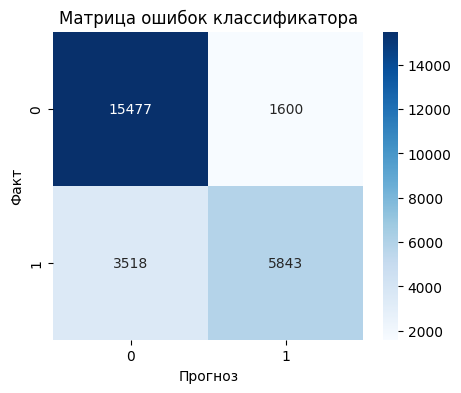

In [12]:
proba_test = model_clf.predict_proba(X_test_encoded)[:, 1]
pred_test = (proba_test > 0.5).astype(int)

# строим матрицу
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(5, 4))

sns.heatmap(
	cm,
	annot=True,
	fmt='d',
	cmap='Blues',
)

plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Матрица ошибок классификатора')
plt.show()

Важность признаков классификатора.

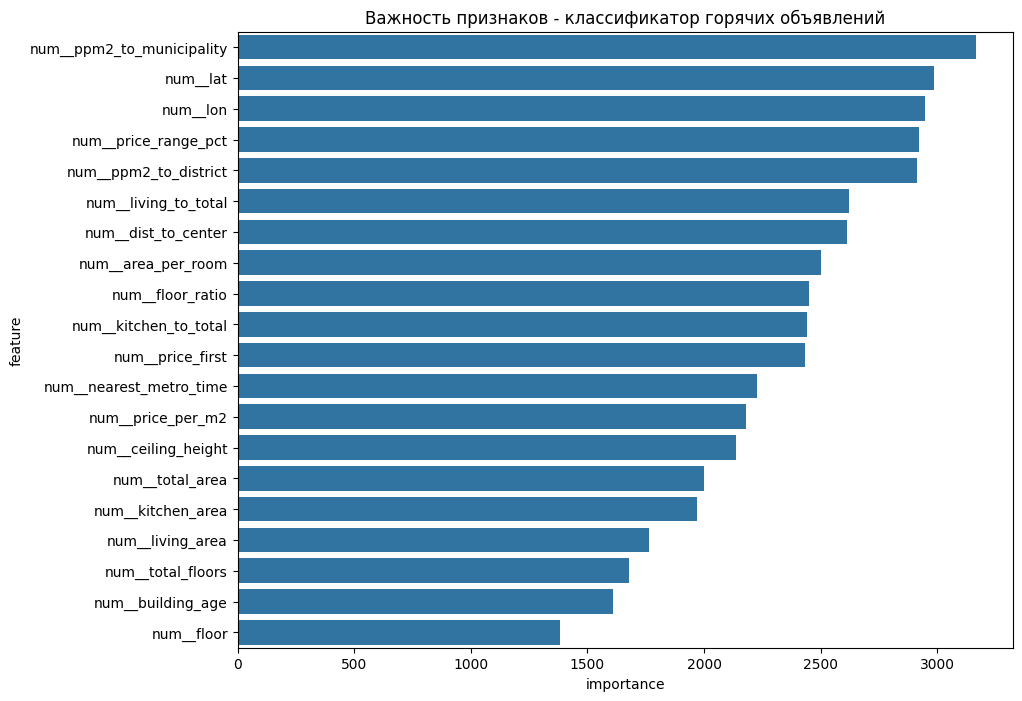

In [13]:
imp_clf = pd.DataFrame({
    'feature': feature_names,
    'importance': model_clf['models'].feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=imp_clf)
plt.title('Важность признаков - классификатор горячих объявлений')
plt.show()

# Модель 2 - регрессор точных дней (сегмент < 30 дней)

Теперь обучаем регрессию только на горячем сегменте (объявления, ушедшие быстрее 30 дней)

Кодирование то же самое, целевой признак - days_on_market

In [14]:
# Оставляем только горячий сегмент
df_hot = df[df['days_on_market'] < HOT]
print('Горячих объявлений:', len(df_hot))

y_reg = df_hot['days_on_market'].astype(float)
X_reg = df_hot.drop(columns='days_on_market')

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

num_cols, cat_cols = col_names_func(X_train)
preprocessor = preprocessor_creator(cat_cols, num_cols)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

display(X_train_encoded.shape)
display(X_test_encoded.shape)

Горячих объявлений: 46803


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [10, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(37442, 382)

(9361, 382)

In [15]:
pipe_reg = Pipeline([('models', LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))])
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

simple_reg_params = [
        # Линейная регрессия
        {
            'models': [LinearRegression()]
        },

        # Дерево решений
        {
            'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
            'models__max_depth': [6, 9, 12],
            'models__min_samples_leaf': [30, 60]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    simple_reg_params,
    n_iter=5,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_simple_reg = rscv.fit(X_train_encoded, y_train)
simple_reg = rscv_simple_reg.best_estimator_

print('Лучшая простая модель:', simple_reg['models'])
print('Метрики на тесте')
evaluate_model(y_test, simple_reg.predict(X_test_encoded))

Лучшая простая модель: DecisionTreeRegressor(max_depth=12, min_samples_leaf=30, random_state=42)
Метрики на тесте
MAE: 5.44
RMSE: 6.87
R2: 0.252


(5.43650340853683, np.float64(6.874323993297676), 0.25223302994919117)

In [16]:
boosters_reg_params = [
        # LGBM
        {
            'models': [LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)],
            'models__n_estimators': [500, 900, 1500],
            'models__learning_rate': [0.03, 0.05],
            'models__num_leaves': [63, 127],
            'models__subsample': [0.8, 1.0],
            'models__colsample_bytree': [0.7, 1.0],
            'models__reg_lambda': [0.0, 1.0]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    boosters_reg_params,
    n_iter=10,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_boost_reg = rscv.fit(X_train_encoded, y_train)
model_reg = rscv_boost_reg.best_estimator_

print('Лучший бустинг:', model_reg['models'])
print('Метрики лучшей модели на трейне')
evaluate_model(y_train, model_reg.predict(X_train_encoded))
print()
print('Метрики лучшей модели на тесте')
evaluate_model(y_test, model_reg.predict(X_test_encoded))

Лучший бустинг: LGBMRegressor(colsample_bytree=0.7, learning_rate=0.03, n_estimators=500,
              num_leaves=63, random_state=42, subsample=0.8, verbose=-1)
Метрики лучшей модели на трейне


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 4.36
RMSE: 5.50
R2: 0.523

Метрики лучшей модели на тесте
MAE: 5.09
RMSE: 6.45
R2: 0.342


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


(5.087371924044058, np.float64(6.449356773555634), 0.3418284755970712)

Важность признаков регрессора.

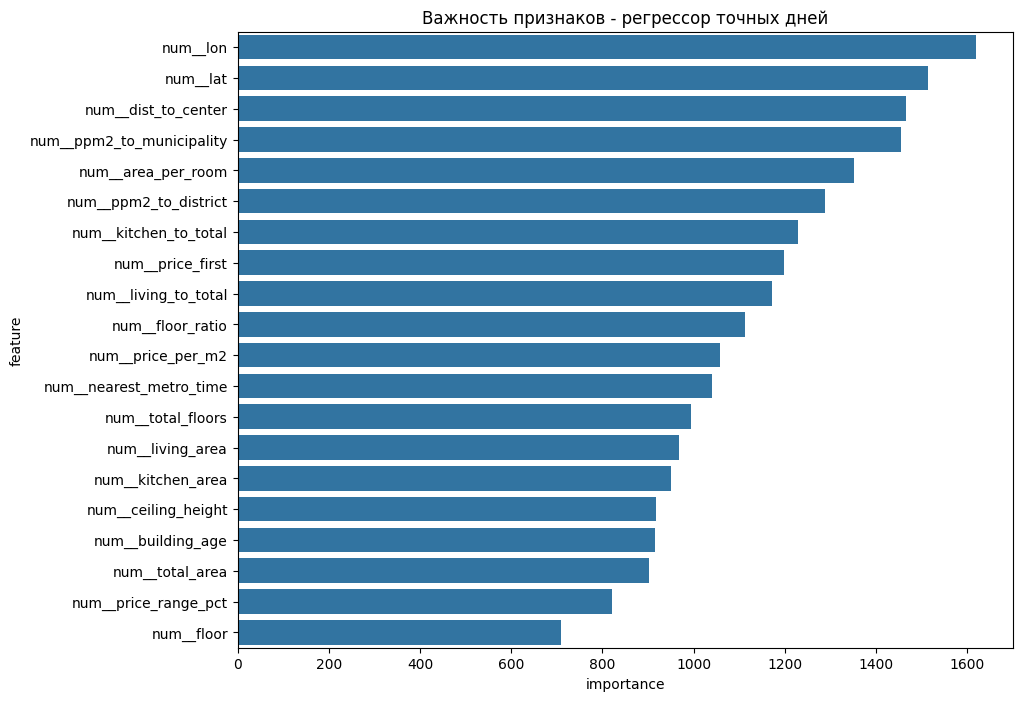

In [17]:
imp_reg = pd.DataFrame({
    'feature': feature_names,
    'importance': model_reg['models'].feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=imp_reg)
plt.title('Важность признаков - регрессор точных дней')
plt.show()

Самые важные признаки для модели регрессии - это показатели переоценённости квартиры относительно других (ppm2_to_district и ppm2_to_municipality) и её расположения (даже просто голые координаты дают сигнал)

### Нейросеть

In [18]:
# импорт нейронки
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# если в системе есть видеокарта - считаем на ней
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Устройство для обучения:', device)

# переводим данные в тензоры
X_train_dense = X_train_encoded.toarray().astype('float32')
X_test_dense = X_test_encoded.toarray().astype('float32')

X_train_t = torch.tensor(X_train_dense)
X_test_t = torch.tensor(X_test_dense)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# заворачиваем трейн в DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

print('Размер обучающей матрицы:', X_train_t.shape)

Устройство для обучения: cuda
Размер обучающей матрицы: torch.Size([37442, 382])


In [19]:
# Простая полносвязная нейросеть
class Net(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# отправляем нейронку на GPU
model = Net(X_train_t.shape[1]).to(device)
print(model)

Net(
  (fc1): Linear(in_features=382, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)


In [20]:
# берём mse как функцию потерь
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# задаём количество эпох
epochs = 100
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        # переносим батч на видеокарту
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # средняя ошибка за эпоху по всем батчам
    mean_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f'Эпоха {epoch + 1}/{epochs}, ошибка (MSE): {mean_loss:.3f}')

Эпоха 10/100, ошибка (MSE): 52.340
Эпоха 20/100, ошибка (MSE): 50.517
Эпоха 30/100, ошибка (MSE): 49.327
Эпоха 40/100, ошибка (MSE): 48.634
Эпоха 50/100, ошибка (MSE): 47.531
Эпоха 60/100, ошибка (MSE): 46.689
Эпоха 70/100, ошибка (MSE): 46.550
Эпоха 80/100, ошибка (MSE): 45.209
Эпоха 90/100, ошибка (MSE): 44.730
Эпоха 100/100, ошибка (MSE): 44.376


In [21]:
# смотрим качество на тесте
# переводим модель в режим оценки (eval)
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_t.to(device)).cpu().numpy().reshape(-1)

print('Метрики нейросети на тесте')
evaluate_model(y_test, y_pred_nn)

Метрики нейросети на тесте
MAE: 5.50
RMSE: 6.76
R2: 0.276


(5.503430345682186, np.float64(6.764647318441968), 0.27590324343418204)

# Выводы

Под задачу ликвидности обучены две независимые модели:

**Классификатор**

- ROC-AUC - 0.844 уверенно отделяет лоты, которые уйдут менее, чем за месяц. Лучшая модель - lgbm
- Главные сигналы: микро-локация (координаты, расстояние до центра, относительная цена по району/округу ppm2_to_district/ppm2_to_municipality), параметры дома (тип, новостройка/готовность, ремонт), цена за м2

**Регрессор**

- RMSE - 7, MAE - 6 дней. Точный день в основном предсказывается за счёт локации и цены, а не конкретных метрик квартиры
- Топ-сигналы те же, что у классификатора: локация и относительная цена.
